# 🔭 Planet Classification — Enhanced Transfer Learning
**Features:** Data Augmentation · Class Weights · Image Analysis & Enhancement · Softmax Classification · Auto Test-Set Injection

In [1]:
import os
import shutil
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms, models

from PIL import Image, ImageEnhance, ImageFilter, ImageStat
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [2]:
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [3]:
# Dataset paths
train_dir = r"C:\Users\ahmed\Documents\projects\deeplearning project\astronomical recognition\data\raw\Planets and Moons"
test_dir  = r"C:\Users\ahmed\Documents\projects\deeplearning project\astronomical recognition\data\test"

# Output paths
save_model_path = r"C:\Users\ahmed\Documents\projects\deeplearning project\astronomical recognition\results\checkpoints\transfer_learning\best_model.pth"
csv_log_path    = r"C:\Users\ahmed\Documents\projects\deeplearning project\astronomical recognition\results\checkpoints\transfer_learning\training_log.csv"

for path in [train_dir, test_dir]:
    if not os.path.exists(path):
        raise FileNotFoundError(f"Directory not found: {path}")

os.makedirs(os.path.dirname(save_model_path), exist_ok=True)

## 🎲 Data Augmentation
Extended pipeline tailored for astronomical images: spatial transforms, photometric jitter, blur simulation, and Gaussian noise injection.

In [4]:
# ── Custom: Gaussian Noise ───────────────────────────────────────────────────
class AddGaussianNoise(object):
    """Injects Gaussian noise to simulate sensor noise in telescope imagery."""
    def __init__(self, mean=0.0, std=0.02):
        self.mean = mean
        self.std  = std

    def __call__(self, tensor):
        return tensor + torch.randn_like(tensor) * self.std + self.mean

    def __repr__(self):
        return f'AddGaussianNoise(mean={self.mean}, std={self.std})'


# ── Train Transform ──────────────────────────────────────────────────────────
# IMPORTANT: RandomErasing operates on TENSORS, not PIL Images.
# It must come AFTER ToTensor() + Normalize(). All PIL-based transforms
# (crop, flip, jitter, blur) must come BEFORE ToTensor().
train_transform = transforms.Compose([
    # --- PIL-based transforms (must be before ToTensor) ---
    transforms.RandomResizedCrop(224, scale=(0.65, 1.0), ratio=(0.85, 1.15)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=180),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.08, 0.08),
        scale=(0.9, 1.1),
        shear=5
    ),
    transforms.RandomPerspective(distortion_scale=0.2, p=0.3),
    transforms.ColorJitter(
        brightness=0.4,
        contrast=0.4,
        saturation=0.3,
        hue=0.08
    ),
    transforms.RandomGrayscale(p=0.10),
    transforms.RandomApply([
        transforms.GaussianBlur(kernel_size=5, sigma=(0.1, 2.0))
    ], p=0.3),

    # --- Convert to tensor FIRST ---
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),

    # --- Tensor-based transforms (must be after ToTensor) ---
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.10), ratio=(0.3, 3.3)),
    AddGaussianNoise(mean=0.0, std=0.015),
])


# ── Val / Test Transform ─────────────────────────────────────────────────────
val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

print('Augmentation pipeline ready.')
print(f'  Train stages : {len(train_transform.transforms)}')
print(f'  Val stages   : {len(val_transform.transforms)}')


Augmentation pipeline ready.
  Train stages : 13
  Val stages   : 4


In [5]:
# ── Build train / val image lists ────────────────────────────────────────────
train_images = []
val_images   = []
class_to_idx = {}
classes = sorted(os.listdir(train_dir))

for idx, cls in enumerate(classes):
    class_to_idx[cls] = idx
    cls_path = os.path.join(train_dir, cls)
    images = [
        os.path.join(cls_path, f)
        for f in os.listdir(cls_path)
        if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.tiff'))
    ]
    train_imgs, val_imgs = train_test_split(images, test_size=0.2, random_state=seed)
    train_images += [(img, idx) for img in train_imgs]
    val_images   += [(img, idx) for img in val_imgs]

print(f"Classes ({len(classes)}): {classes}")
print(f"Train samples : {len(train_images)}")
print(f"Val   samples : {len(val_images)}")

Classes (11): ['Earth', 'Jupiter', 'MakeMake', 'Mars', 'Mercury', 'Moon', 'Neptune', 'Pluto', 'Saturn', 'Uranus', 'Venus']
Train samples : 1305
Val   samples : 329


## ⚖️ Class Weights
Inverse-frequency weighting compensates for class imbalance in the training set.

In [6]:
# ── Compute per-class weights ─────────────────────────────────────────────────
label_counts = Counter([label for _, label in train_images])
num_classes  = len(classes)

counts_tensor = torch.tensor(
    [label_counts[i] for i in range(num_classes)], dtype=torch.float
)

# Inverse-frequency: w_c = N / (C * n_c)
N = counts_tensor.sum()
class_weights = N / (num_classes * counts_tensor)
class_weights = class_weights / class_weights.sum() * num_classes   # re-scale so mean ≈ 1
class_weights = class_weights.to(device)

print("Class weights (higher = rarer class):")
for cls, w in zip(classes, class_weights.cpu().numpy()):
    bar = '█' * int(w * 10)
    print(f"  {cls:<12}  {w:.4f}  {bar}")

Class weights (higher = rarer class):
  Earth         0.9968  █████████
  Jupiter       0.9968  █████████
  MakeMake      0.9968  █████████
  Mars          0.9968  █████████
  Mercury       0.9968  █████████
  Moon          1.0315  ██████████
  Neptune       0.9968  █████████
  Pluto         0.9968  █████████
  Saturn        0.9968  █████████
  Uranus        0.9968  █████████
  Venus         0.9968  █████████


In [7]:
class PlanetDataset(Dataset):
    def __init__(self, image_list, transform=None):
        self.image_list = image_list
        self.transform  = transform

    def __len__(self):
        return len(self.image_list)

    def __getitem__(self, idx):
        img_path, label = self.image_list[idx]
        img = Image.open(img_path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, label


train_ds = PlanetDataset(train_images, transform=train_transform)
val_ds   = PlanetDataset(val_images,   transform=val_transform)
test_ds  = datasets.ImageFolder(test_dir, transform=val_transform)

# CRITICAL FIX — Windows + CUDA + num_workers > 0:
# PyTorch DataLoader spawns worker subprocesses. On Windows each subprocess
# tries to re-initialise CUDA, which is illegal in a forked process.
# The loader falls back silently to CPU-side buffering, making the GPU appear
# idle even though 'Using device: cuda' was printed. Solution: num_workers=0.
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,
                          num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False,
                          num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False,
                          num_workers=0, pin_memory=True)

print(f"DataLoaders ready — train: {len(train_loader)} batches | "
      f"val: {len(val_loader)} batches | test: {len(test_loader)} batches")


DataLoaders ready — train: 41 batches | val: 11 batches | test: 1 batches


## 🧠 Model — ResNet18 with Partial Fine-Tuning
Layers 3 & 4 + FC are unfrozen for domain adaptation; earlier layers keep ImageNet features.

In [8]:
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Freeze all layers first
for param in model.parameters():
    param.requires_grad = False

# Unfreeze layer3, layer4, and the new FC head
for name, param in model.named_parameters():
    if any(layer in name for layer in ['layer3', 'layer4', 'fc']):
        param.requires_grad = True

# Replace classification head → outputs logits over `num_classes`
num_ftrs = model.fc.in_features
model.fc = nn.Sequential(
    nn.Dropout(p=0.4),
    nn.Linear(num_ftrs, 256),
    nn.ReLU(),
    nn.Dropout(p=0.3),
    nn.Linear(256, num_classes)
    # NOTE: No Softmax here — CrossEntropyLoss expects raw logits.
    # Softmax is applied explicitly at inference time (see classification cell).
)

model = model.to(device)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"Trainable params: {trainable:,} / {total:,}  ({100*trainable/total:.1f}%)")

Trainable params: 10,627,595 / 11,310,667  (94.0%)


In [9]:
# ── Loss with class weights ────────────────────────────────────────────────────
criterion = nn.CrossEntropyLoss(weight=class_weights)

# ── Optimizer: different LRs for different layer groups ───────────────────────
optimizer = optim.Adam([
    {'params': model.layer3.parameters(), 'lr': 5e-5},
    {'params': model.layer4.parameters(), 'lr': 1e-4},
    {'params': model.fc.parameters(),     'lr': 1e-3},
], weight_decay=1e-4)

# ── Scheduler: reduce LR when val loss plateaus ───────────────────────────────
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5, verbose=True
)

print("Criterion : CrossEntropyLoss with class weights")
print("Optimizer : Adam (layer-wise LR)")
print("Scheduler : ReduceLROnPlateau (factor=0.5, patience=5)")

Criterion : CrossEntropyLoss with class weights
Optimizer : Adam (layer-wise LR)
Scheduler : ReduceLROnPlateau (factor=0.5, patience=5)


c:\Users\ahmed\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


## Pre-Training: Populate Missing Test Classes
Iterates every class in `train_dir`. Any planet whose `Test_<cls>` folder is absent or empty
gets one randomly selected training image copied in, then `test_loader` is rebuilt.

In [10]:
IMG_EXTS = ('.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.webp')

def _has_images_recursive(folder):
    """Return True if folder contains any image file in any subdirectory."""
    for root, dirs, files in os.walk(folder):
        for f in files:
            if f.lower().endswith(IMG_EXTS):
                return True
    return False


def populate_test_set(train_dir, test_dir, classes):
    """
    Ensures every planet class has a test image.

    Structure expected by ImageFolder:  test_dir/Test_<cls>/<image.jpg>
    If a Test_<cls> folder already contains images (at any depth) it is
    left untouched.  Otherwise one random image is copied from training.
    """
    global test_ds, test_loader
    print('Checking test-set coverage...\n')
    injected = 0

    for cls in classes:
        test_cls_dir  = os.path.join(test_dir,  f'Test_{cls}')
        train_cls_dir = os.path.join(train_dir, cls)

        # Check recursively — handles nested layouts like Test_Earth/Earth/img.jpg
        if os.path.isdir(test_cls_dir) and _has_images_recursive(test_cls_dir):
            count = sum(
                1 for _, _, files in os.walk(test_cls_dir)
                for f in files if f.lower().endswith(IMG_EXTS)
            )
            print(f'  OK   Test_{cls:<12} has {count} image(s) — skip.')
            continue

        if not os.path.isdir(train_cls_dir):
            print(f'  SKIP {cls:<14} not found in train_dir.')
            continue

        candidates = [f for f in os.listdir(train_cls_dir)
                      if f.lower().endswith(IMG_EXTS)]
        if not candidates:
            print(f'  SKIP {cls:<14} training folder is empty.')
            continue

        chosen   = random.choice(candidates)
        src_path = os.path.join(train_cls_dir, chosen)
        # Place image directly inside Test_<cls>/ (flat, not nested)
        os.makedirs(test_cls_dir, exist_ok=True)
        dst_path = os.path.join(test_cls_dir, chosen)
        shutil.copy2(src_path, dst_path)
        print(f'  INJ  Test_{cls:<12} <- "{chosen}" copied from training data.')
        injected += 1

    # Rebuild test_ds and test_loader with the updated folders
    test_ds     = datasets.ImageFolder(test_dir, transform=val_transform)
    test_loader = DataLoader(test_ds, batch_size=32, shuffle=False,
                             num_workers=0, pin_memory=True)

    print(f'\n{"-"*52}')
    print(f'  Injected  : {injected} new class folder(s)')
    print(f'  Test total: {len(test_ds)} images in {len(test_ds.classes)} classes')
    print(f'  Folders   : {test_ds.classes}')
    print(f'{"-"*52}')


populate_test_set(train_dir, test_dir, classes)


Checking test-set coverage...

  OK   Test_Earth        has 1 image(s) — skip.
  OK   Test_Jupiter      has 1 image(s) — skip.
  OK   Test_MakeMake     has 1 image(s) — skip.
  OK   Test_Mars         has 1 image(s) — skip.
  OK   Test_Mercury      has 1 image(s) — skip.
  OK   Test_Moon         has 1 image(s) — skip.
  OK   Test_Neptune      has 1 image(s) — skip.
  OK   Test_Pluto        has 1 image(s) — skip.
  OK   Test_Saturn       has 1 image(s) — skip.
  OK   Test_Uranus       has 1 image(s) — skip.
  OK   Test_Venus        has 1 image(s) — skip.

----------------------------------------------------
  Injected  : 0 new class folder(s)
  Test total: 11 images in 11 classes
  Folders   : ['Test_Earth', 'Test_Jupiter', 'Test_MakeMake', 'Test_Mars', 'Test_Mercury', 'Test_Moon', 'Test_Neptune', 'Test_Pluto', 'Test_Saturn', 'Test_Uranus', 'Test_Venus']
----------------------------------------------------


In [11]:
# GPU diagnostics — run before any training to catch silent CPU fallback
assert torch.cuda.is_available(), 'CUDA not available — check your driver/PyTorch build.'

model_device = next(model.parameters()).device
print(f'Model device       : {model_device}')
print(f'Criterion weight   : {criterion.weight.device}')
print(f'GPU name           : {torch.cuda.get_device_name(0)}')
print(f'VRAM total         : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

assert 'cuda' in str(model_device), \
    f'Model is on {model_device} — call model.to(device) again before training.'
assert 'cuda' in str(criterion.weight.device), \
    f'criterion.weight is on CPU — re-run the class-weights cell.'

torch.cuda.empty_cache()
print('GPU ready.\n')

# Mixed-precision scaler: runs forward + backward in FP16 on GPU tensor cores.
# This is the fastest way to confirm the GPU is doing real work — watch VRAM
# usage climb in Task Manager / nvidia-smi once the first epoch starts.
scaler = torch.cuda.amp.GradScaler()

epochs    = 50
best_acc  = 0.0
patience  = 12
counter   = 0
history   = []

for epoch in range(epochs):

    # Train ───────────────────────────────────────────────────────────────────
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        # non_blocking=True overlaps host→device transfer with GPU compute
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)   # frees gradient memory faster

        with torch.cuda.amp.autocast():         # FP16 forward on GPU
            outputs = model(images)
            loss    = criterion(outputs, labels)

        scaler.scale(loss).backward()           # scaled FP16 backward
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)

    # Validate ────────────────────────────────────────────────────────────────
    model.eval()
    val_loss = 0.0
    correct  = 0
    total    = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            with torch.cuda.amp.autocast():
                outputs = model(images)
                loss    = criterion(outputs, labels)

            val_loss += loss.item()
            probs     = F.softmax(outputs, dim=1)
            preds     = torch.argmax(probs, dim=1)
            correct  += (preds == labels).sum().item()
            total    += labels.size(0)

    val_loss /= len(val_loader)
    val_acc   = correct / total
    scheduler.step(val_loss)

    vram_mb = torch.cuda.memory_reserved(0) / 1e6
    print(f'Epoch {epoch+1:02d}/{epochs}  |  '
          f'Train Loss: {train_loss:.4f}  |  '
          f'Val Loss: {val_loss:.4f}  |  '
          f'Val Acc: {val_acc:.4f}  |  '
          f'VRAM: {vram_mb:.0f} MB')

    history.append({
        'epoch':        epoch + 1,
        'train_loss':   train_loss,
        'val_loss':     val_loss,
        'val_accuracy': val_acc
    })
    pd.DataFrame(history).to_csv(csv_log_path, index=False)

    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), save_model_path)
        print('  Saved best model')
        counter = 0
    else:
        counter += 1

    if counter >= patience:
        print(f'Early stopping at epoch {epoch+1}  (best={best_acc:.4f})')
        break

torch.cuda.synchronize()
print(f'\nTraining complete.  Best Val Accuracy: {best_acc:.4f}')


Model device       : cuda:0
Criterion weight   : cuda:0
GPU name           : NVIDIA GeForce RTX 4050 Laptop GPU
VRAM total         : 6.4 GB
GPU ready.



C:\Users\ahmed\AppData\Local\Temp\ipykernel_25280\3724843392.py:21: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
C:\Users\ahmed\AppData\Local\Temp\ipykernel_25280\3724843392.py:42: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():         # FP16 forward on GPU
C:\Users\ahmed\AppData\Local\Temp\ipykernel_25280\3724843392.py:67: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 01/50  |  Train Loss: 0.8528  |  Val Loss: 0.0135  |  Val Acc: 1.0000  |  VRAM: 394 MB
  Saved best model


C:\Users\ahmed\AppData\Local\Temp\ipykernel_25280\3724843392.py:42: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():         # FP16 forward on GPU
C:\Users\ahmed\AppData\Local\Temp\ipykernel_25280\3724843392.py:67: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 02/50  |  Train Loss: 0.1269  |  Val Loss: 0.0033  |  Val Acc: 1.0000  |  VRAM: 394 MB


...

Epoch 11/50  |  Train Loss: 0.0250  |  Val Loss: 0.0000  |  Val Acc: 1.0000  |  VRAM: 394 MB


C:\Users\ahmed\AppData\Local\Temp\ipykernel_25280\3724843392.py:42: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():         # FP16 forward on GPU
C:\Users\ahmed\AppData\Local\Temp\ipykernel_25280\3724843392.py:67: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 12/50  |  Train Loss: 0.0289  |  Val Loss: 0.0000  |  Val Acc: 1.0000  |  VRAM: 394 MB


C:\Users\ahmed\AppData\Local\Temp\ipykernel_25280\3724843392.py:42: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():         # FP16 forward on GPU
C:\Users\ahmed\AppData\Local\Temp\ipykernel_25280\3724843392.py:67: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 13/50  |  Train Loss: 0.0334  |  Val Loss: 0.0000  |  Val Acc: 1.0000  |  VRAM: 394 MB
Early stopping at epoch 13  (best=1.0000)

Training complete.  Best Val Accuracy: 1.0000


## 🔬 Image Analysis & Enhancement Pipeline
Before inference, each image is fully analysed (brightness, contrast, sharpness, noise) and adaptively enhanced to produce the clearest possible input for the model.

In [19]:
def analyze_image(img: Image.Image) -> dict:
    """
    Computes a comprehensive set of quality metrics for an astronomical image.
    Returns a dict with brightness, contrast, sharpness, noise, and colour stats.
    """
    stat = ImageStat.Stat(img)

    # Per-channel mean brightness (0–255)
    brightness = float(np.mean(stat.mean))

    # Per-channel std-dev → proxy for RMS contrast
    contrast = float(np.mean(stat.stddev))

    # Sharpness: variance of Laplacian on grayscale
    gray = np.array(img.convert("L"), dtype=np.float32)
    laplacian = np.array([
        [0,  1, 0],
        [1, -4, 1],
        [0,  1, 0]
    ], dtype=np.float32)
    from scipy.ndimage import convolve as sp_convolve
    lap_img = sp_convolve(gray, laplacian)
    sharpness = float(np.var(lap_img))

    # Noise estimate: std-dev of a flat region (top-left 16×16 corner)
    corner = gray[:16, :16]
    noise_estimate = float(np.std(corner))

    # Dynamic range (max - min on grayscale)
    dynamic_range = float(gray.max() - gray.min())

    # Channel balance (ratio of R:G:B means)
    r_mean, g_mean, b_mean = stat.mean[0], stat.mean[1], stat.mean[2]

    return {
        "brightness"    : round(brightness, 2),
        "contrast_rms"  : round(contrast, 2),
        "sharpness_lap" : round(sharpness, 2),
        "noise_estimate": round(noise_estimate, 2),
        "dynamic_range" : round(dynamic_range, 2),
        "channel_R_mean": round(r_mean, 2),
        "channel_G_mean": round(g_mean, 2),
        "channel_B_mean": round(b_mean, 2),
        "resolution"    : img.size,
    }


def enhance_image(img: Image.Image, report: dict) -> Image.Image:
    """
    Adaptively enhances an image based on its analysis report.
    Applies only the corrections that are actually needed.
    """
    enhanced = img.copy()
    log = []

    # ── 1. Brightness normalisation ───────────────────────────────────────────
    b = report["brightness"]
    if b < 60:
        factor = min(2.0, 120 / (b + 1e-6))
        enhanced = ImageEnhance.Brightness(enhanced).enhance(factor)
        log.append(f"Brightness ↑ ×{factor:.2f} (was {b:.1f})")
    elif b > 210:
        factor = max(0.6, 180 / (b + 1e-6))
        enhanced = ImageEnhance.Brightness(enhanced).enhance(factor)
        log.append(f"Brightness ↓ ×{factor:.2f} (was {b:.1f})")

    # ── 2. Contrast boost ─────────────────────────────────────────────────────
    c = report["contrast_rms"]
    if c < 35:
        enhanced = ImageEnhance.Contrast(enhanced).enhance(1.6)
        log.append(f"Contrast ↑ ×1.60 (rms={c:.1f})")
    elif c < 55:
        enhanced = ImageEnhance.Contrast(enhanced).enhance(1.25)
        log.append(f"Contrast ↑ ×1.25 (rms={c:.1f})")

    # ── 3. Sharpness / detail recovery ────────────────────────────────────────
    s = report["sharpness_lap"]
    if s < 200:
        enhanced = ImageEnhance.Sharpness(enhanced).enhance(2.5)
        enhanced = enhanced.filter(ImageFilter.UnsharpMask(radius=2, percent=150, threshold=3))
        log.append(f"Sharpness ↑ ×2.50 + UnsharpMask (var={s:.1f})")
    elif s < 800:
        enhanced = ImageEnhance.Sharpness(enhanced).enhance(1.5)
        log.append(f"Sharpness ↑ ×1.50 (var={s:.1f})")

    # ── 4. Noise reduction (when noise is high relative to contrast) ──────────
    n = report["noise_estimate"]
    if n > 20 and report["contrast_rms"] < 60:
        enhanced = enhanced.filter(ImageFilter.MedianFilter(size=3))
        log.append(f"Median denoise applied (noise={n:.1f})")

    # ── 5. Edge enhancement detail pass ──────────────────────────────────────
    enhanced = enhanced.filter(ImageFilter.DETAIL)
    log.append("Detail filter applied")

    return enhanced, log


def analyze_and_enhance(img_path: str, verbose: bool = True):
    """
    Full pipeline: load → analyse → enhance → return enhanced PIL image.
    """
    img = Image.open(img_path).convert("RGB")
    report = analyze_image(img)
    enhanced_img, steps = enhance_image(img, report)

    if verbose:
        print("\n📊 Image Analysis Report")
        print(f"  {'Metric':<20} {'Value'}")
        print("  " + "-" * 35)
        for k, v in report.items():
            print(f"  {k:<20} {v}")
        print("\n🛠  Enhancement Steps Applied:")
        for step in steps:
            print(f"  • {step}")

    return enhanced_img, report


print("✅ analyze_and_enhance() pipeline ready.")

✅ analyze_and_enhance() pipeline ready.


## 📥 Auto Test-Set Injection
If a requested planet class is absent from the test directory, a random image is sourced from the training set, enhanced, and injected into the test directory automatically.

In [20]:
def ensure_test_image(
    planet_name: str,
    train_dir: str,
    test_dir: str,
    enhance: bool = True
) -> str:
    """
    Returns a path to a test image for `planet_name`.

    Logic:
    ──────
    1. Look for  <test_dir>/Test_<planet_name>/  (your naming convention).
    2. If found with images  → return a random one.
    3. If NOT found (or empty) →
         a. Pick a random image from <train_dir>/<planet_name>/
         b. Optionally enhance it (full analysis + adaptive pipeline)
         c. Save it into <test_dir>/Test_<planet_name>/
         d. Reload test_loader so the new sample is included in future evaluations.
         e. Return the saved path.

    Parameters
    ----------
    planet_name : str   e.g. 'Mars', 'Saturn'
    train_dir   : str   root training directory
    test_dir    : str   root test directory
    enhance     : bool  whether to run the analysis+enhancement pipeline before saving

    Returns
    -------
    str  — absolute path to the (potentially newly injected) test image
    """
    IMG_EXTS = ('.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.webp')

    # ── Step 1: check test directory ─────────────────────────────────────────
    test_class_dir = os.path.join(test_dir, f"Test_{planet_name}")

    if os.path.isdir(test_class_dir):
        existing = [
            f for f in os.listdir(test_class_dir)
            if f.lower().endswith(IMG_EXTS)
        ]
        if existing:
            chosen = random.choice(existing)
            path   = os.path.join(test_class_dir, chosen)
            print(f"✅ Found '{planet_name}' in test set → {path}")
            return path

    # ── Step 2: fallback — source from training data ──────────────────────────
    print(f"⚠️  '{planet_name}' not found in test set. Sourcing from training data…")

    train_class_dir = os.path.join(train_dir, planet_name)
    if not os.path.isdir(train_class_dir):
        raise FileNotFoundError(
            f"Class '{planet_name}' not found in train_dir either.\n"
            f"Available classes: {sorted(os.listdir(train_dir))}"
        )

    candidates = [
        f for f in os.listdir(train_class_dir)
        if f.lower().endswith(IMG_EXTS)
    ]
    if not candidates:
        raise FileNotFoundError(f"No images in training class folder: {train_class_dir}")

    src_filename = random.choice(candidates)
    src_path     = os.path.join(train_class_dir, src_filename)

    # ── Step 3: enhance and save ──────────────────────────────────────────────
    os.makedirs(test_class_dir, exist_ok=True)
    prefix   = "enhanced_" if enhance else "fallback_"
    dst_path = os.path.join(test_class_dir, prefix + src_filename)

    if enhance:
        enhanced_img, report = analyze_and_enhance(src_path, verbose=True)
        enhanced_img.save(dst_path)
        print(f"  💾 Enhanced image saved → {dst_path}")
    else:
        shutil.copy2(src_path, dst_path)
        print(f"  💾 Image copied → {dst_path}")

    # ── Step 4: refresh the test dataset & loader ─────────────────────────────
    global test_ds, test_loader
    test_ds     = datasets.ImageFolder(test_dir, transform=val_transform)
    test_loader = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
    print(f"  🔄 test_loader refreshed — total test samples: {len(test_ds)}")

    return dst_path


print("✅ ensure_test_image() ready.")
print("Usage: path = ensure_test_image('Saturn', train_dir, test_dir)")

✅ ensure_test_image() ready.
Usage: path = ensure_test_image('Saturn', train_dir, test_dir)


## 🔭 Softmax Classification
Full inference pipeline: analyse → enhance → classify with ranked softmax probabilities.

In [21]:
def classify_planet(
    img_path: str,
    model,
    classes: list,
    device,
    run_analysis: bool = True,
    top_k: int = 5
):
    """
    Classifies a single planet image using the trained model.

    Pipeline
    ────────
    1. Analyse image quality (brightness, contrast, sharpness, noise)
    2. Apply adaptive enhancement
    3. Run model forward pass → logits
    4. Apply Softmax → probability distribution over all 11 classes
    5. Display top-k predictions with confidence bars
    6. Show original vs enhanced side by side

    Returns
    -------
    pred_class : str      Predicted planet name
    probs      : ndarray  Full softmax probability vector (length = num_classes)
    """
    IMG_MEAN = [0.485, 0.456, 0.406]
    IMG_STD  = [0.229, 0.224, 0.225]

    infer_transform = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(IMG_MEAN, IMG_STD),
    ])

    original_img = Image.open(img_path).convert("RGB")

    # ── Analysis + Enhancement ────────────────────────────────────────────────
    if run_analysis:
        enhanced_img, report = analyze_and_enhance(img_path, verbose=True)
    else:
        enhanced_img = original_img
        report = None

    # ── Forward pass ──────────────────────────────────────────────────────────
    tensor = infer_transform(enhanced_img).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        logits = model(tensor)                      # raw logits
        probs  = F.softmax(logits, dim=1)           # softmax over all classes
        probs  = probs.squeeze().cpu().numpy()

    # ── Ranked results ────────────────────────────────────────────────────────
    top_idx = np.argsort(probs)[::-1][:top_k]
    pred_class = classes[top_idx[0]]

    print("\n🔭 Softmax Classification Results:")
    print(f"  {'Rank':<6} {'Planet':<14} {'Prob':>7}  {'Bar'}")
    print("  " + "─" * 50)
    for rank, idx in enumerate(top_idx, 1):
        p   = probs[idx]
        bar = '█' * int(p * 40) + '░' * (40 - int(p * 40))
        star = " ◀ PREDICTION" if rank == 1 else ""
        print(f"  #{rank:<5} {classes[idx]:<14} {p*100:>6.2f}%  {bar}{star}")

    # ── Visual comparison: original vs enhanced ───────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].imshow(original_img)
    axes[0].set_title("Original", fontsize=13)
    axes[0].axis('off')

    axes[1].imshow(enhanced_img)
    axes[1].set_title(f"Enhanced → Predicted: {pred_class} ({probs[top_idx[0]]*100:.1f}%)",
                      fontsize=13, color='steelblue', fontweight='bold')
    axes[1].axis('off')
    plt.tight_layout()
    plt.show()

    # ── Probability bar chart ─────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(10, 4))
    colours = ['#2196F3' if i == top_idx[0] else '#90CAF9' for i in range(len(classes))]
    ax.barh(classes, probs * 100, color=colours)
    ax.set_xlabel("Softmax Probability (%)")
    ax.set_title(f"Class Probabilities — {pred_class}")
    ax.set_xlim(0, 100)
    for i, p in enumerate(probs):
        ax.text(p * 100 + 0.5, i, f"{p*100:.1f}%", va='center', fontsize=9)
    plt.tight_layout()
    plt.show()

    return pred_class, probs


print("✅ classify_planet() with Softmax ready.")
print("\nUsage examples:")
print("  # Classify a known test image:")
print("  pred, probs = classify_planet(img_path, model, classes, device)")
print()
print("  # Auto-inject if missing, then classify:")
print("  path = ensure_test_image('MakeMake', train_dir, test_dir)")
print("  pred, probs = classify_planet(path, model, classes, device)")

✅ classify_planet() with Softmax ready.

Usage examples:
  # Classify a known test image:
  pred, probs = classify_planet(img_path, model, classes, device)

  # Auto-inject if missing, then classify:
  path = ensure_test_image('MakeMake', train_dir, test_dir)
  pred, probs = classify_planet(path, model, classes, device)


## 🚀 Example: Classify a Planet (with auto-injection fallback)

C:\Users\ahmed\AppData\Local\Temp\ipykernel_25280\1287086226.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(save_model_path, map_locati

✅ Found 'Saturn' in test set → C:\Users\ahmed\Documents\projects\deeplearning project\astronomical recognition\data\test\Test_Saturn\Saturn (130).jpg

📊 Image Analysis Report
  Metric               Value
  -----------------------------------
  brightness           211.38
  contrast_rms         42.08
  sharpness_lap        325.03
  noise_estimate       15.15
  dynamic_range        183.0
  channel_R_mean       212.38
  channel_G_mean       211.36
  channel_B_mean       210.4
  resolution           (256, 144)

🛠  Enhancement Steps Applied:
  • Brightness ↓ ×0.85 (was 211.4)
  • Contrast ↑ ×1.25 (rms=42.1)
  • Sharpness ↑ ×1.50 (var=325.0)
  • Detail filter applied

🔭 Softmax Classification Results:
  Rank   Planet            Prob  Bar
  ──────────────────────────────────────────────────
  #1     Saturn          99.17%  ███████████████████████████████████████░ ◀ PREDICTION
  #2     Pluto            0.44%  ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░
  #3     Earth            0.13%  ░░░░░░░░░░░

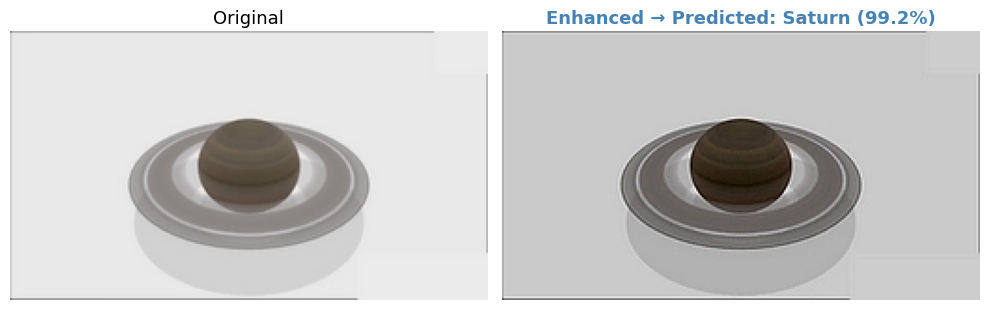

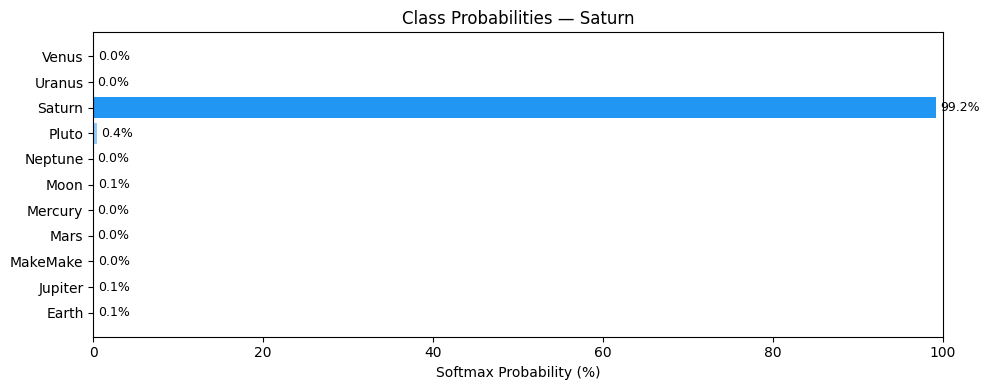

In [22]:
# Load the best checkpoint
model.load_state_dict(torch.load(save_model_path, map_location=device))
model.eval()

# ── Choose a planet to classify ───────────────────────────────────────────────
target_planet = "Saturn"   # ← change this to any class name

# Automatically finds or injects the image into the test set
img_path = ensure_test_image(target_planet, train_dir, test_dir)

# Classify with full analysis, enhancement, and softmax
predicted_class, softmax_probs = classify_planet(
    img_path, model, classes, device,
    run_analysis=True,
    top_k=5
)

## 📈 Full Test-Set Evaluation

In [23]:
model.load_state_dict(torch.load(save_model_path, map_location=device))
model.eval()

all_preds  = []
all_labels = []
all_probs  = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        logits = model(images)
        probs  = F.softmax(logits, dim=1)        # softmax probabilities
        preds  = torch.argmax(probs, dim=1)       # predicted class index
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())

test_acc = np.mean(np.array(all_preds) == np.array(all_labels))
print(f"Test Accuracy: {test_acc:.4f} ({test_acc*100:.1f}%)")

C:\Users\ahmed\AppData\Local\Temp\ipykernel_25280\1920076374.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(save_model_path, map_locati

Test Accuracy: 1.0000 (100.0%)


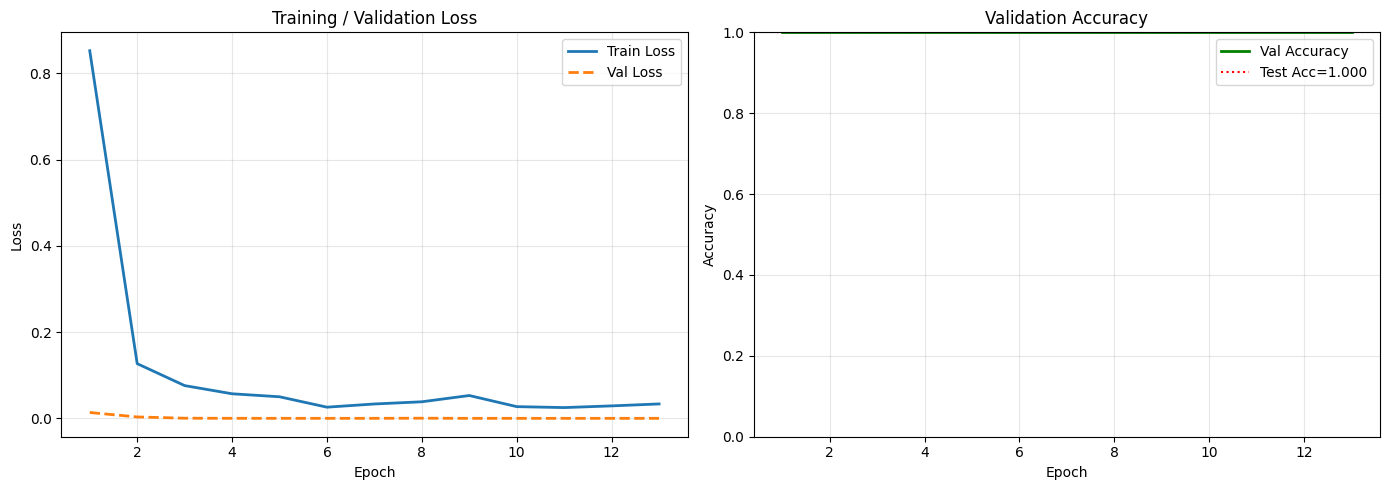

In [24]:
log = pd.read_csv(csv_log_path)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(log['epoch'], log['train_loss'], label='Train Loss', linewidth=2)
axes[0].plot(log['epoch'], log['val_loss'],   label='Val Loss',   linewidth=2, linestyle='--')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training / Validation Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(log['epoch'], log['val_accuracy'], label='Val Accuracy', linewidth=2, color='green')
axes[1].axhline(y=test_acc, color='red', linestyle=':', label=f'Test Acc={test_acc:.3f}')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Validation Accuracy')
axes[1].set_ylim(0, 1)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

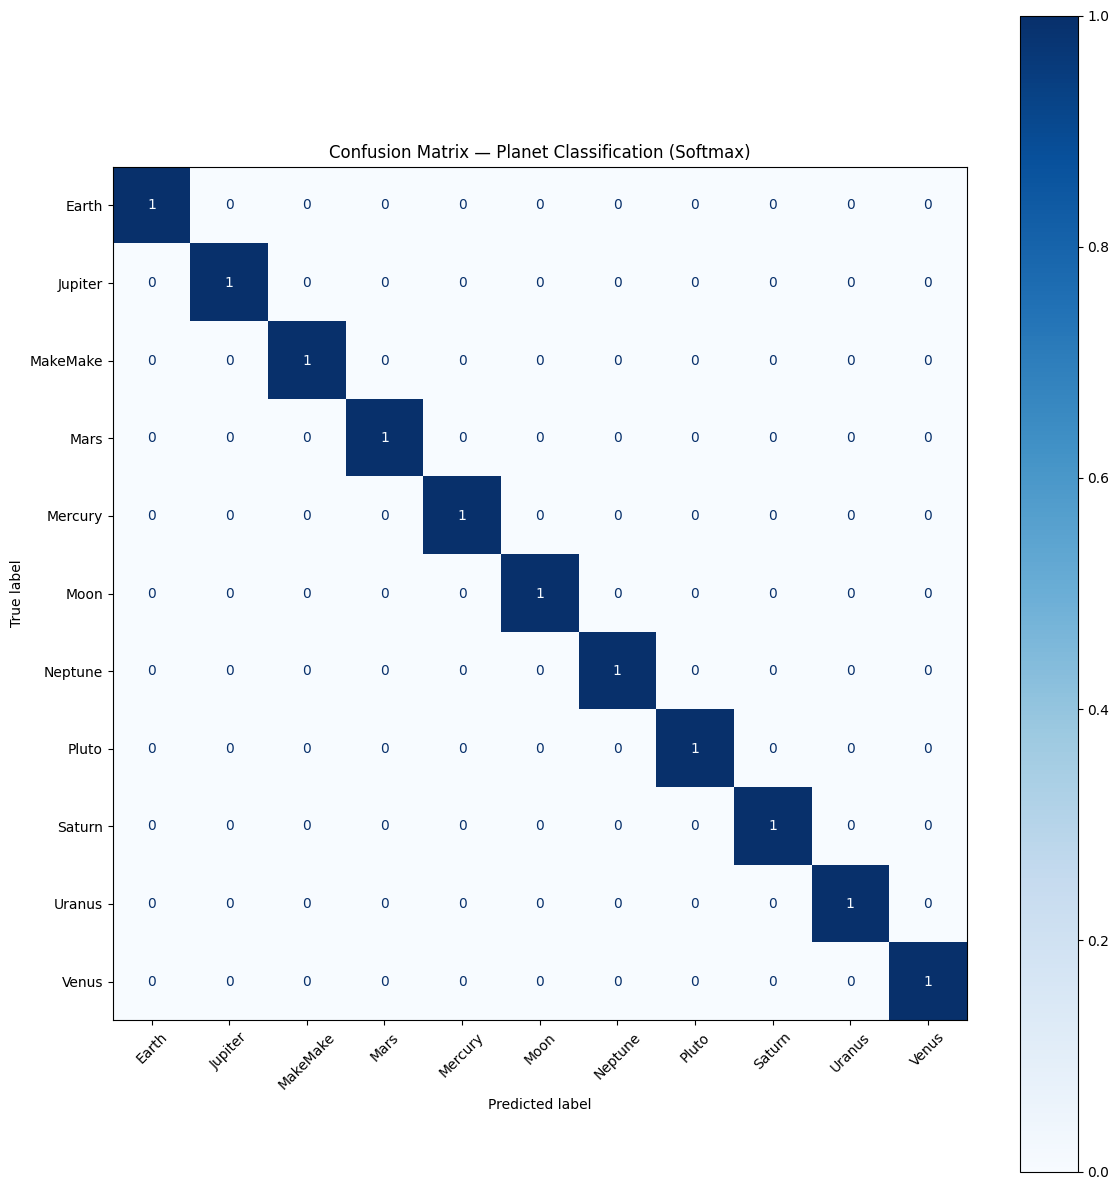


Per-class accuracy:
  Earth        100.0%  (1/1)
  Jupiter      100.0%  (1/1)
  MakeMake     100.0%  (1/1)
  Mars         100.0%  (1/1)
  Mercury      100.0%  (1/1)
  Moon         100.0%  (1/1)
  Neptune      100.0%  (1/1)
  Pluto        100.0%  (1/1)
  Saturn       100.0%  (1/1)
  Uranus       100.0%  (1/1)
  Venus        100.0%  (1/1)


In [25]:
full_classes = [
    'Earth', 'Jupiter', 'MakeMake', 'Mars', 'Mercury', 'Moon',
    'Neptune', 'Pluto', 'Saturn', 'Uranus', 'Venus'
]

# test_ds.class_to_idx maps folder names -> indices
# e.g. {'Test_Earth': 0, 'Test_Jupiter': 1, ...}
# Strip the 'Test_' prefix to get the canonical planet name.
test_mapping       = test_ds.class_to_idx          # <-- was test_dataset (wrong)
idx_to_folder_name = {v: k for k, v in test_mapping.items()}

corrected_labels = []
skip = False
for label in all_labels:
    if skip:
        break
    folder_name = idx_to_folder_name[label]
    # Handle both 'Test_Earth' and plain 'Earth' folder names
    planet_name = folder_name.replace('Test_', '')
    if planet_name not in full_classes:
        print(f'  Class "{planet_name}" not in full_classes — check folder names.')
        print(f'  Folder names seen: {list(idx_to_folder_name.values())}')
        skip = True
        break
    corrected_labels.append(full_classes.index(planet_name))

if not skip:
    # Only include classes that actually appear in the test set
    present_names = sorted(set(
        idx_to_folder_name[v].replace('Test_', '')
        for v in test_mapping.values()
    ))
    present_idx = [full_classes.index(n) for n in present_names if n in full_classes]
    display_labels = [full_classes[i] for i in present_idx]

    cm = confusion_matrix(corrected_labels, all_preds, labels=present_idx)

    fig, ax = plt.subplots(figsize=(12, 12))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels)
    disp.plot(include_values=True, cmap=plt.cm.Blues, ax=ax,
              xticks_rotation=45, values_format='d')
    plt.title('Confusion Matrix — Planet Classification (Softmax)')
    plt.tight_layout()
    plt.show()

    # Per-class accuracy summary
    print('\nPer-class accuracy:')
    for i, name in zip(present_idx, display_labels):
        row = cm[present_idx.index(i)]
        acc = row[present_idx.index(i)] / row.sum() if row.sum() > 0 else 0
        print(f'  {name:<12} {acc*100:5.1f}%  ({row[present_idx.index(i)]}/{row.sum()})')
